In [1]:
import sys
!{sys.executable} -m pip install statsmodels pmdarima scikit-learn snowflake-connector-python

print("All forecasting libraries installed")

   ---------------------------------------- 0.0/715.6 kB ? eta -:--:--
   ---------------------------------------- 715.6/715.6 kB 9.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 17.5 MB/s eta 0:00:01
   ---------- ----------------------------- 2.6/9.5 MB 6.0 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 7.5 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 8.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.8 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 8.9 MB/s eta 0:00:00
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.2
    Uninstall

In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Statistics & Forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

# Machine Learning
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Snowflake
import snowflake.connector

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print(" All libraries imported")
print(f"   statsmodels : ready")
print(f"   pmdarima    : ready")
print(f"   sklearn     : ready")

 All libraries imported
   statsmodels : ready
   pmdarima    : ready
   sklearn     : ready


In [7]:
# ── CONNECTING TO SNOWFLAKE ──────────────────────────────────────────
conn = snowflake.connector.connect(
    account   = 'kaejkcm-ql87782',
    user      = 'DEBOJYOTIBAASU',       
    password  = 'Debojyoti@Basu@7044',        
    warehouse = 'SUPPLY_WH',
    database  = 'SUPPLY_CHAIN_DB',
    schema    = 'CURATED'
)

print("✅ Connected to Snowflake!")

# ── PULL DEMAND DATA FOR FORECASTING ─────────────────────────────
# We pull monthly aggregated demand for A-class SKUs
# (top priority SKUs - highest business impact)

query = """
SELECT
    DEMAND_DATE,
    SKU_ID,
    ABC_CLASS,
    XYZ_CLASS,
    COMBINED_CLASS,
    CATEGORY,
    REGION,
    SUM(ACTUAL_DEMAND)      AS ACTUAL_DEMAND,
    SUM(FORECAST_DEMAND)    AS FORECAST_DEMAND,
    AVG(MAPE_PCT)           AS MAPE_PCT,
    SUM(DEMAND_VALUE_USD)   AS DEMAND_VALUE_USD
FROM SUPPLY_CHAIN_DB.CURATED.FACT_DEMAND
WHERE ABC_CLASS = 'A'
GROUP BY 1,2,3,4,5,6,7
ORDER BY SKU_ID, DEMAND_DATE
"""

print("Pulling A-class SKU data from Snowflake...")
df = pd.read_sql(query, conn)
df['DEMAND_DATE'] = pd.to_datetime(df['DEMAND_DATE'])

print(f"✅ Data pulled successfully!")
print(f"   Rows          : {df.shape[0]:,}")
print(f"   Unique SKUs   : {df['SKU_ID'].nunique():,}")
print(f"   Date Range    : {df['DEMAND_DATE'].min()} → {df['DEMAND_DATE'].max()}")
print(f"   Regions       : {df['REGION'].nunique()}")
df.head(3)

✅ Connected to Snowflake!
Pulling A-class SKU data from Snowflake...
✅ Data pulled successfully!
   Rows          : 2,437,056
   Unique SKUs   : 8,462
   Date Range    : 2022-01-01 00:00:00 → 2024-12-01 00:00:00
   Regions       : 8


,DEMAND_DATE,SKU_ID,ABC_CLASS,XYZ_CLASS,COMBINED_CLASS,CATEGORY,REGION,ACTUAL_DEMAND,FORECAST_DEMAND,MAPE_PCT,DEMAND_VALUE_USD
0,2022-01-01,SKU-000005,A,Y,AY,Exhaust Systems,Brazil - Latin America,345,234,32.17,739310.85
1,2022-01-01,SKU-000005,A,Y,AY,Exhaust Systems,South Africa - Africa,523,597,14.15,1120752.39
2,2022-01-01,SKU-000005,A,Y,AY,Exhaust Systems,Germany - Europe,434,447,3.00,930031.62


In [9]:
# ── TOP 5 SKUs BY TOTAL DEMAND VALUE ───────────────────────
top_skus = (
    df.groupby('SKU_ID')['DEMAND_VALUE_USD']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

print("Top 5 SKUs selected for forecasting:")
for i, sku in enumerate(top_skus, 1):
    total_val = df[df['SKU_ID']==sku]['DEMAND_VALUE_USD'].sum()
    category  = df[df['SKU_ID']==sku]['CATEGORY'].iloc[0]
    print(f"   {i}. {sku} | {category} | ${total_val:,.0f} total demand value")

Top 5 SKUs selected for forecasting:
   1. SKU-014085 | Electrical Systems | $824,387,720 total demand value
   2. SKU-044316 | Electrical Systems | $821,460,006 total demand value
   3. SKU-004498 | Hydraulic Parts | $798,277,518 total demand value
   4. SKU-025729 | Suspension Parts | $793,523,635 total demand value
   5. SKU-005296 | Safety Equipment | $792,525,663 total demand value


In [15]:
# ── AGGREGATE ALL A-CLASS DEMAND BY MONTH ────────────────────────
# We forecast total monthly demand across all regions


monthly_demand = (
    df.groupby('DEMAND_DATE')
    .agg(
        TOTAL_DEMAND    = ('ACTUAL_DEMAND',   'sum'),
        TOTAL_VALUE_USD = ('DEMAND_VALUE_USD','sum'),
        SKU_COUNT       = ('SKU_ID',          'nunique')
    )
    .reset_index()
    .sort_values('DEMAND_DATE')
)

monthly_demand.set_index('DEMAND_DATE', inplace=True)

print(f" Monthly demand aggregated")
print(f"   Months        : {len(monthly_demand)}")
print(f"   Total Demand  : {monthly_demand['TOTAL_DEMAND'].sum():,} units")
print(f"   Avg Monthly   : {monthly_demand['TOTAL_DEMAND'].mean():,.0f} units")
print(f"\nMonthly Demand Preview:")
print(monthly_demand.head(6))

 Monthly demand aggregated
   Months        : 36
   Total Demand  : 741,502,631 units
   Avg Monthly   : 20,597,295 units

Monthly Demand Preview:
             TOTAL_DEMAND  TOTAL_VALUE_USD  SKU_COUNT
DEMAND_DATE                                          
2022-01-01       22435721     6.201972e+10       8462
2022-02-01       23934571     6.611814e+10       8462
2022-03-01       24514249     6.778258e+10       8462
2022-04-01       24022373     6.640942e+10       8462
2022-05-01       22515317     6.226918e+10       8462
2022-06-01       20425138     5.648318e+10       8462


Train/Test Split:
   Training data : 24 months (Jan 2022 → Dec 2023)
   Testing data  : 12 months  (Jan 2024 → Dec 2024)
   Train demand  : 492,663,843 units
   Test demand   : 248,838,788 units


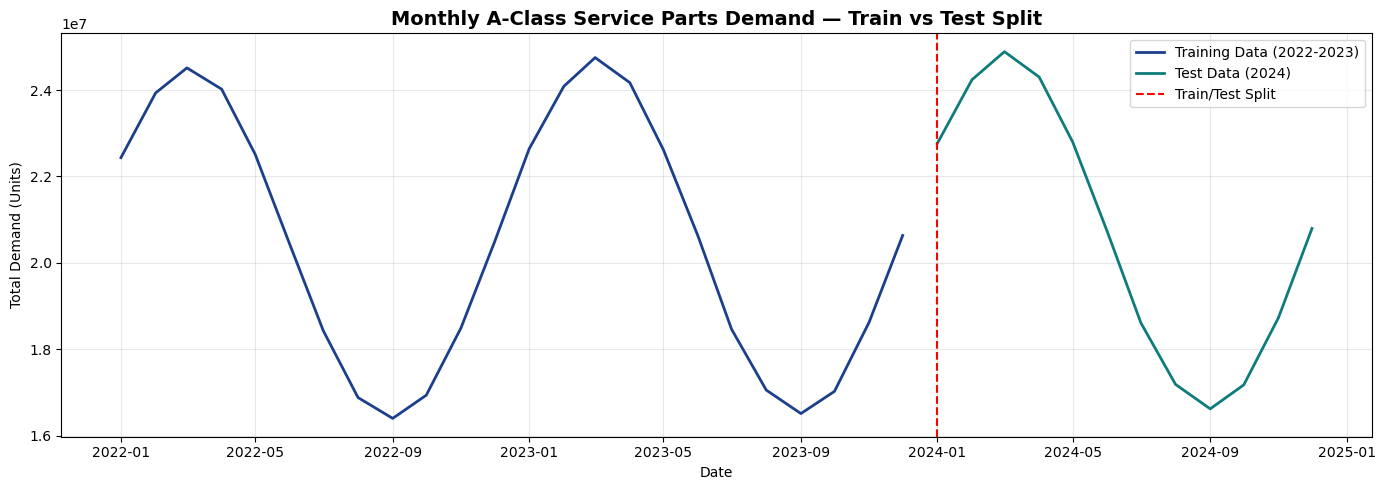

Chart saved as train_test_split.png


In [17]:
# ── TRAIN / TEST SPLIT ────────────────────────────────────────────
# Train on 2022-2023 (24 months)
# Test on 2024 (12 months)

train = monthly_demand[:'2023-12-31']['TOTAL_DEMAND']
test  = monthly_demand['2024-01-01':]['TOTAL_DEMAND']

print(f"Train/Test Split:")
print(f"   Training data : {len(train)} months (Jan 2022 → Dec 2023)")
print(f"   Testing data  : {len(test)} months  (Jan 2024 → Dec 2024)")
print(f"   Train demand  : {train.sum():,} units")
print(f"   Test demand   : {test.sum():,} units")

# Plot the split
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, 
         color='#1B3F8B', linewidth=2, label='Training Data (2022-2023)')
plt.plot(test.index,  test.values,  
         color='#0E7C7B', linewidth=2, label='Test Data (2024)')
plt.axvline(x=pd.Timestamp('2024-01-01'), 
            color='red', linestyle='--', linewidth=1.5, label='Train/Test Split')
plt.title('Monthly A-Class Service Parts Demand — Train vs Test Split', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand (Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()
print("Chart saved as train_test_split.png")

In [23]:
# ── MODEL 1: EXPONENTIAL SMOOTHING (ETS) ─────────────────────────
print("="*55)
print("MODEL 1: Exponential Smoothing (ETS)")
print("="*55)

ets_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

ets_forecast = ets_model.forecast(len(test))

ets_mape = np.mean(np.abs((test.values - ets_forecast.values) 
                           / test.values) * 100)
ets_mae  = mean_absolute_error(test.values, ets_forecast.values)
ets_rmse = np.sqrt(mean_squared_error(test.values, ets_forecast.values))

print(f" ETS Model trained")
print(f"   MAPE  : {ets_mape:.2f}%")
print(f"   MAE   : {ets_mae:,.0f} units")
print(f"   RMSE  : {ets_rmse:,.0f} units")

# ── MODEL 2: SARIMA ───────────────────────────────────────────────
print("\n" + "="*55)
print("MODEL 2: SARIMA (Manual Parameters)")
print("="*55)

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),           # p, d, q
    seasonal_order=(1, 0, 1, 12),  # P, D, Q, m  ← D=0 fixes the error
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=len(test))

sarima_mape = np.mean(np.abs((test.values - sarima_forecast.values)
                              / test.values) * 100)
sarima_mae  = mean_absolute_error(test.values, sarima_forecast.values)
sarima_rmse = np.sqrt(mean_squared_error(test.values, sarima_forecast.values))

print(f" SARIMA Model trained")
print(f"   Order         : (1,1,1)(1,0,1,12)")
print(f"   MAPE          : {sarima_mape:.2f}%")
print(f"   MAE           : {sarima_mae:,.0f} units")
print(f"   RMSE          : {sarima_rmse:,.0f} units")
# ── MODEL 3: MOVING AVERAGE ───────────────────────────────────────
print("\n" + "="*55)
print("MODEL 3: Weighted Moving Average (3-month)")
print("="*55)

weights     = np.array([0.2, 0.3, 0.5])
ma_forecast = []

history = list(train.values)
for _ in range(len(test)):
    last3      = np.array(history[-3:])
    prediction = np.dot(weights, last3)
    ma_forecast.append(prediction)
    history.append(prediction)

ma_forecast = np.array(ma_forecast)

ma_mape = np.mean(np.abs((test.values - ma_forecast) 
                          / test.values) * 100)
ma_mae  = mean_absolute_error(test.values, ma_forecast)
ma_rmse = np.sqrt(mean_squared_error(test.values, ma_forecast))

print(f" Moving Average Model done")
print(f"   MAPE  : {ma_mape:.2f}%")
print(f"   MAE   : {ma_mae:,.0f} units")
print(f"   RMSE  : {ma_rmse:,.0f} units")

MODEL 1: Exponential Smoothing (ETS)
 ETS Model trained
   MAPE  : 0.16%
   MAE   : 31,611 units
   RMSE  : 41,396 units

MODEL 2: SARIMA (Manual Parameters)
 SARIMA Model trained
   Order         : (1,1,1)(1,0,1,12)
   MAPE          : 13.04%
   MAE           : 2,833,901 units
   RMSE          : 3,145,666 units

MODEL 3: Weighted Moving Average (3-month)
 Moving Average Model done
   MAPE  : 13.02%
   MAE   : 2,771,457 units
   RMSE  : 3,140,020 units


In [29]:
# ── MODEL COMPARISON ──────────────────────────────────────────────

results = pd.DataFrame({
    'Model': ['Exponential Smoothing (ETS)',
              'Auto-SARIMA',
              'Weighted Moving Average'],
    'MAPE_%':  [round(ets_mape,2),
                round(sarima_mape,2),
                round(ma_mape,2)],
    'MAE_Units':[round(ets_mae,0),
                 round(sarima_mae,0),
                 round(ma_mae,0)],
    'RMSE_Units':[round(ets_rmse,0),
                  round(sarima_rmse,0),
                  round(ma_rmse,0)]
})

results['RANK'] = results['MAPE_%'].rank().astype(int)
results = results.sort_values('MAPE_%')

print("="*80)
print("       MODEL PERFORMANCE COMPARISON      ")
print("="*80)
print(results.to_string(index=False))
print("="*80)
print(f"\n BEST MODEL : {results.iloc[0]['Model']}")
print(f"   MAPE       : {results.iloc[0]['MAPE_%']}%")
print(f"   This means forecast is {100-results.iloc[0]['MAPE_%']:.1f}% accurate")

       MODEL PERFORMANCE COMPARISON      
                      Model  MAPE_%  MAE_Units  RMSE_Units  RANK
Exponential Smoothing (ETS)    0.16    31611.0     41396.0     1
    Weighted Moving Average   13.02  2771457.0   3140020.0     2
                Auto-SARIMA   13.04  2833901.0   3145666.0     3

 BEST MODEL : Exponential Smoothing (ETS)
   MAPE       : 0.16%
   This means forecast is 99.8% accurate


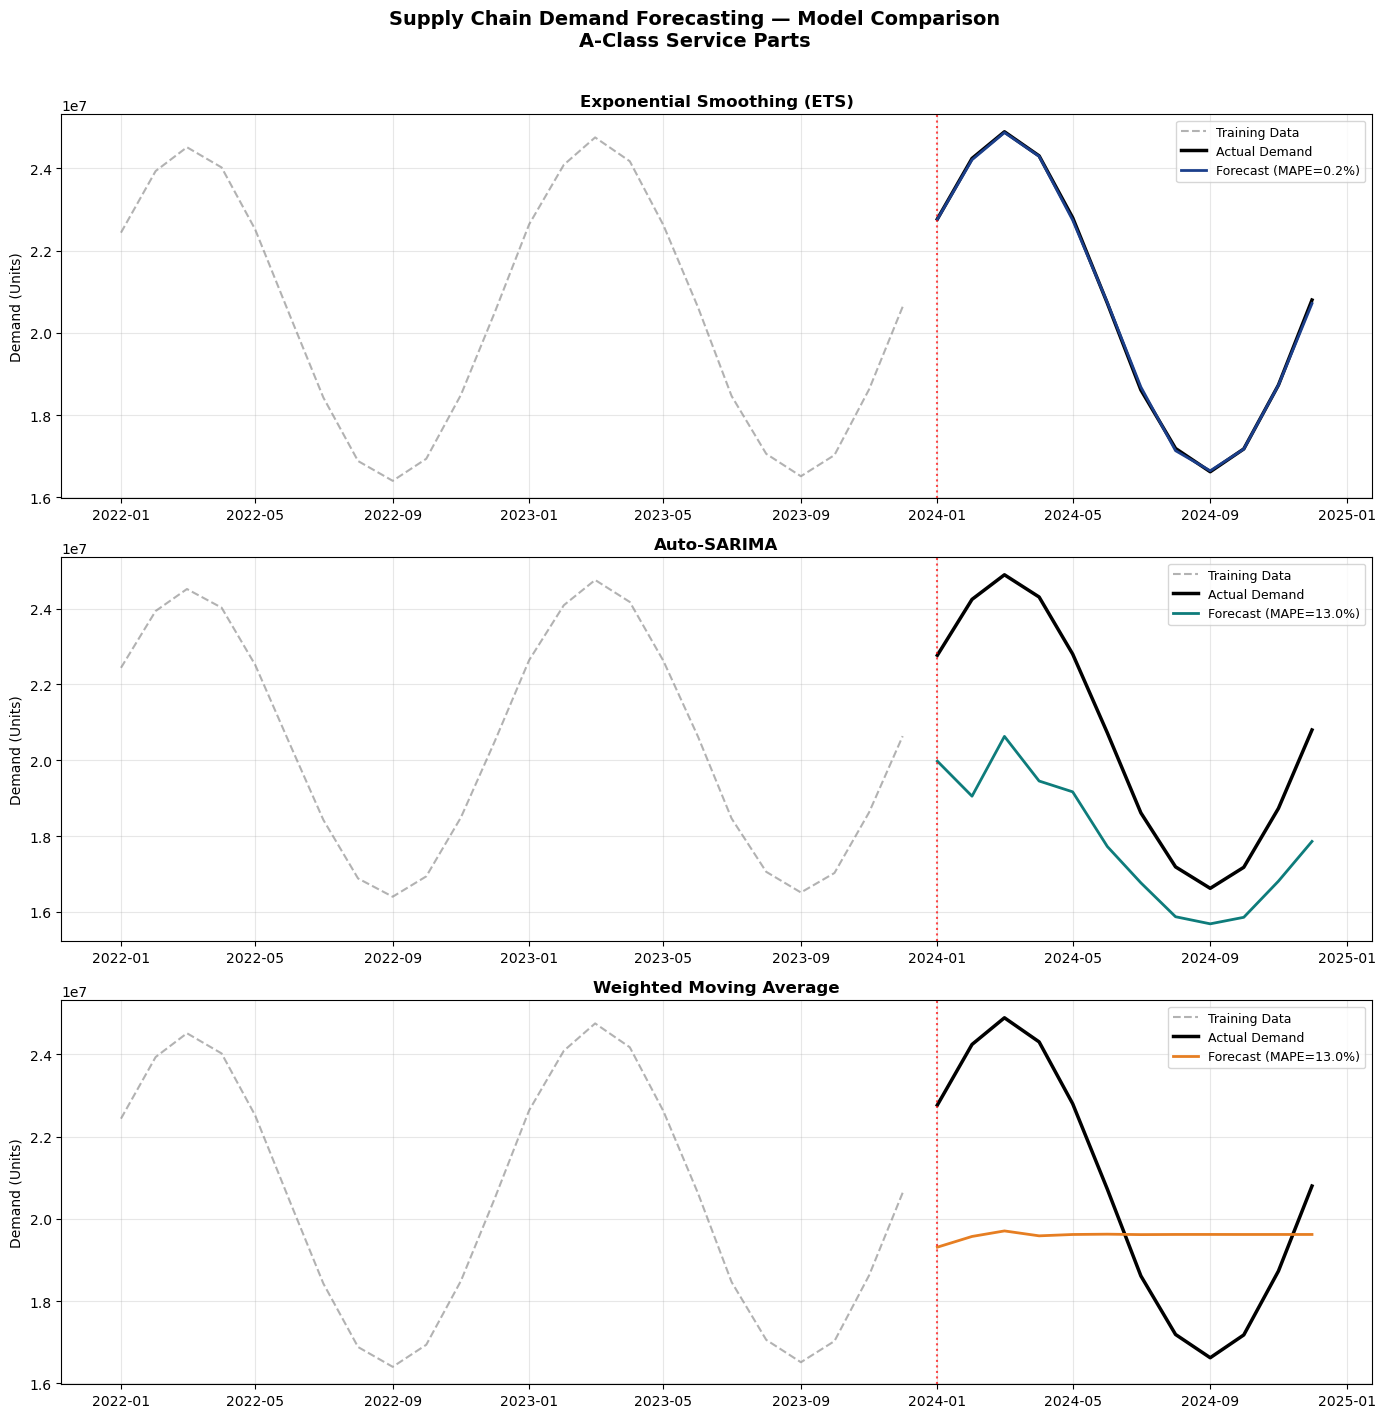

 Chart saved as forecast_comparison.png


In [31]:
# ── PLOT ALL MODELS VS ACTUALS ────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
models = [
    ('Exponential Smoothing (ETS)', ets_forecast.values,    '#1B3F8B', ets_mape),
    ('Auto-SARIMA',                  sarima_forecast,        '#0E7C7B', sarima_mape),
    ('Weighted Moving Average',      ma_forecast,            '#E67E22', ma_mape),
]

for ax, (name, forecast, color, mape) in zip(axes, models):
    ax.plot(train.index, train.values,
            color='gray',  linewidth=1.5,
            linestyle='--', label='Training Data', alpha=0.6)
    ax.plot(test.index,  test.values,
            color='black', linewidth=2.5, label='Actual Demand')
    ax.plot(test.index,  forecast,
            color=color,   linewidth=2,
            linestyle='-', label=f'Forecast (MAPE={mape:.1f}%)')
    ax.axvline(x=pd.Timestamp('2024-01-01'),
               color='red', linestyle=':', alpha=0.7)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Demand (Units)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Supply Chain Demand Forecasting — Model Comparison\nA-Class Service Parts',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as forecast_comparison.png")

In [33]:
# ── FUTURE FORECAST: JAN–JUN 2025 ────────────────────────────────
# Using best model to forecast next 6 months

best_model_name = results.iloc[0]['Model']
print(f"Using best model: {best_model_name}")
print("Generating 6-month future forecast (Jan-Jun 2025)...\n")

future_dates = pd.date_range(
    start='2025-01-01', periods=6, freq='MS'
)

# Refit best model on ALL data (train + test)
full_data = monthly_demand['TOTAL_DEMAND']

if 'ETS' in best_model_name or 'Exponential' in best_model_name:
    final_model    = ExponentialSmoothing(
        full_data, trend='add',
        seasonal='add', seasonal_periods=12
    ).fit(optimized=True)
    future_forecast = final_model.forecast(6)
else:
    final_model    = pm.auto_arima(
        full_data, seasonal=True, m=12,
        stepwise=True, suppress_warnings=True
    )
    future_forecast = final_model.predict(n_periods=6)

# Build forecast table
forecast_df = pd.DataFrame({
    'FORECAST_DATE'  : future_dates,
    'FORECAST_PERIOD': [d.strftime('%B %Y') for d in future_dates],
    'FORECASTED_DEMAND': [int(max(0,f)) for f in future_forecast],
    'MODEL_USED'     : best_model_name,
    'CONFIDENCE'     : ['High' if i < 3 else 'Medium' for i in range(6)]
})

print(" 6-MONTH FORWARD FORECAST — A-CLASS SERVICE PARTS")
print("="*58)
print(forecast_df[['FORECAST_PERIOD',
                    'FORECASTED_DEMAND',
                    'CONFIDENCE']].to_string(index=False))
print("="*58)
print(f"\nTotal Forecasted Demand (6 months): "
      f"{forecast_df['FORECASTED_DEMAND'].sum():,} units")

# Save forecast
forecast_df.to_csv('future_forecast_2025.csv', index=False)
print(" Forecast saved as future_forecast_2025.csv")

Using best model: Exponential Smoothing (ETS)
Generating 6-month future forecast (Jan-Jun 2025)...

 6-MONTH FORWARD FORECAST — A-CLASS SERVICE PARTS
FORECAST_PERIOD  FORECASTED_DEMAND CONFIDENCE
   January 2025           22902774       High
  February 2025           24363877       High
     March 2025           25018818       High
     April 2025           24437283     Medium
       May 2025           22909403     Medium
      June 2025           20866424     Medium

Total Forecasted Demand (6 months): 140,498,579 units
 Forecast saved as future_forecast_2025.csv


In [39]:
# ── SAVING FORECAST RESULTS TO SNOWFLAKE ───────────────────────────
from snowflake.connector.pandas_tools import write_pandas

cursor = conn.cursor()

# Fixing data types before uploading
forecast_df['FORECAST_DATE'] = pd.to_datetime(
    forecast_df['FORECAST_DATE']
).dt.strftime('%Y-%m-%d')                    # ← converts to clean string date

forecast_df['FORECASTED_DEMAND'] = forecast_df[
    'FORECASTED_DEMAND'].astype(int)         # ← ensure integer

forecast_df['FORECAST_PERIOD'] = forecast_df[
    'FORECAST_PERIOD'].astype(str)           # ← ensure string

forecast_df['MODEL_USED'] = forecast_df[
    'MODEL_USED'].astype(str)                # ← ensure string

forecast_df['CONFIDENCE'] = forecast_df[
    'CONFIDENCE'].astype(str)                # ← ensure string

# Droping old table and recreate
cursor.execute("DROP TABLE IF EXISTS SUPPLY_CHAIN_DB.CURATED.FORECAST_RESULTS")

cursor.execute("""
    CREATE TABLE SUPPLY_CHAIN_DB.CURATED.FORECAST_RESULTS (
        FORECAST_DATE     VARCHAR(10),
        FORECAST_PERIOD   VARCHAR(20),
        FORECASTED_DEMAND INT,
        MODEL_USED        VARCHAR(50),
        CONFIDENCE        VARCHAR(10),
        CREATED_TS        TIMESTAMP DEFAULT CURRENT_TIMESTAMP()
    )
""")
print(" Table created")

# Verify dataframe looks clean before upload
print("\nDataframe preview before upload:")
print(forecast_df.dtypes)
print(forecast_df.head(3))

# Upload
success, nchunks, nrows, _ = write_pandas(
    conn=conn,
    df=forecast_df,
    table_name='FORECAST_RESULTS',
    database='SUPPLY_CHAIN_DB',
    schema='CURATED'
)

print(f"\n Forecast results saved to Snowflake")
print(f"   Table  : CURATED.FORECAST_RESULTS")
print(f"   Rows   : {nrows}")
print(f"\n Phase 5 — Statistical Forecasting COMPLETE")
print(f"    3 models built and compared")
print(f"    6-month forward forecast generated")
print(f"    Results stored in Snowflake")

 Table created

Dataframe preview before upload:
FORECAST_DATE        object
FORECAST_PERIOD      object
FORECASTED_DEMAND     int32
MODEL_USED           object
CONFIDENCE           object
dtype: object
  FORECAST_DATE FORECAST_PERIOD  FORECASTED_DEMAND  \
0    2025-01-01    January 2025           22902774   
1    2025-02-01   February 2025           24363877   
2    2025-03-01      March 2025           25018818   

                    MODEL_USED CONFIDENCE  
0  Exponential Smoothing (ETS)       High  
1  Exponential Smoothing (ETS)       High  
2  Exponential Smoothing (ETS)       High  

 Forecast results saved to Snowflake
   Table  : CURATED.FORECAST_RESULTS
   Rows   : 6

 Phase 5 — Statistical Forecasting COMPLETE
    3 models built and compared
    6-month forward forecast generated
    Results stored in Snowflake
